# Ontwerp en Analyse van een Nok-Mechanisme

**Vak:** Beweging en Trillingen | **Academiejaar:** 2025–2026

---

## Probleemstelling

We ontwerpen een **roterende nok met verticaal translerende rolvolger**. De kern van het ontwerpprobleem is het vinden van een nokcontour dat de gewenste volgerbeweging realiseert, terwijl tegelijk aan drie mechanische eisen wordt voldaan:

1. **Drukhoek** $\alpha < 30°$: beperkt de wrijvingskracht in de geleiding
2. **Geen ondersnijding**: de kromtestraal van de nok $\rho > R_f$ voor de volledige rotatie
3. **Geen zweefgedrag**: de veer houdt de volger altijd in contact met de nok

---

## Systeemparameters

| Parameter | Symbool | Waarde | Eenheid |
|-----------|---------|--------|---------|
| Cyclustijd | $T_{cyclus}$ | 0.5 | s |
| Basisstraal nok | $R_0$ | 50 | mm |
| Straal volgerwiel | $R_f$ | 15 | mm |
| Excentriciteit | $e$ | 0 | mm |
| Equivalente massa | $m$ | 29 | kg |
| Relatieve demping | $\zeta$ | 0.094 | – |
| Veerstijfheid | $k$ | 25 000 | N/m |
| Veervoorspanning | $F_{preload}$ | 500 | N |

## Bewegingsspecificaties

| Segment | Hoek | Heffing | Bewegingswet |
|---------|------|---------|--------------|
| Heffing 1 | 10° → 65° | 0 → 10 mm | 5e-graads polynoom |
| Stilstand 1 | 65° → 95° | 10 mm | Dwell |
| Heffing 2 | 95° → 210° | 10 → 50 mm | 5e-graads polynoom |
| Terugkeer | 210° → 350° | 50 → 0 mm | 5e-graads polynoom |
| Stilstand 2 | 350° → 10° | 0 mm | Dwell |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
from scipy.fft import fft, fftfreq
import math
import matplotlib.animation as animation

%matplotlib widget

### 1. Invoer van Systeemparameters

De **absolute dempingsconstante** $c$ wordt afgeleid uit de dimensieloze relatieve demping $\zeta$ via:
$$c = \zeta \cdot 2\sqrt{k \cdot m}$$

> **Examentip:** De relatieve demping $\zeta = 0.094$ stelt ons in staat om het systeem te karakteriseren als licht gedempt (onderkritisch). De eigenfrequentie van het veer-massa systeem is $\omega_n = \sqrt{k/m}$. Als de nok sneller wordt aangedreven zodat de excitatie de eigenfrequentie nadert, treedt **resonantie** op en explodeert de amplitude.


In [2]:
# Tijds- en snelheidsgegevens
T_cyclus = 0.5                     # Cyclustijd in s
omega = 2.0 * np.pi / T_cyclus     # Toerental in rad/s

# Nokgeometrie
R_0 = 0.050                        # Basisstraal nok in m
R_f = 0.015                        # Straal volgerwiel in m
e = 0.0                            # Excentriciteit volger in m

# Krachten, massa en wrijving
m_volger = 29.0                    # Equivalente massa in kg
mu = 0.1                           # Wrijvingscoëfficiënt
g = 9.81                           # Zwaartekrachtvalversnelling in m/s^2

# Veer en demper
zeta = 0.094                       # Relatieve demping
k_veer = 25000.0                   # Veerstijfheid in N/m
F_preload = 500.0                  # Mechanische voorspanning in N
c_demping = zeta * 2 * np.sqrt(k_veer * m_volger) # Absolute dempingsconstante in Ns/m

# Vliegwiel parameters
K_gewenst = 0.05                   # Fluctuatiecoëfficiënt

### 2. Bewegingswetten (genormaliseerd)

Elke bewegingswet werkt met een **genormaliseerde parameter** $\tau \in [0, 1]$ en geeft **dimensieloze** functies terug $(y, y', y'', y''')$. De werkelijke kinematica volgt via de **kettingregel**:

$$s = h \cdot y(\tau), \quad \dot{s} = \frac{h}{\beta}\cdot y'(\tau) \cdot \omega, \quad \ddot{s} = \frac{h}{\beta^2}\cdot y''(\tau) \cdot \omega^2$$

waarbij $h$ de heffing [m] en $\beta$ de nokhoekinterval [rad] van het segment is.

#### Gekozen bewegingswet: 5e-graads polynoom

$$y(\tau) = 10\tau^3 - 15\tau^4 + 6\tau^5$$

**Eigenschappen:**
- Continu tot en met de **versnellingscurve** (klasse $C^2$): geen schokken in $\ddot{s}$
- De ruk $\dddot{s}$ heeft eindige sprongen aan de segmentranden — acceptabel
- Goede balans tussen piekversnelling en zachtheid

> **Trade-off (mondelinge vraag):** Waarom geen cycloid? De cycloid heeft een lagere piekversnelling, maar een hogere ruk. De 5e-graads polynoom heeft een hogere piekversnelling maar is "zachter" voor het mechanisme. De keuze hangt af van de gevoeligheid voor trilling vs. piekbelasting op de motor.


In [3]:
def dwell_law(tau):
    zeros = np.zeros_like(tau)
    return zeros, zeros, zeros, zeros

def cycloid_law(tau):
    y = tau - np.sin(2 * np.pi * tau) / (2 * np.pi)
    dy = 1.0 - np.cos(2 * np.pi * tau)
    ddy = 2 * np.pi * np.sin(2 * np.pi * tau)
    dddy = 4 * np.pi**2 * np.cos(2 * np.pi * tau)
    return y, dy, ddy, dddy

def poly5_law(tau):
    y = 10 * tau**3 - 15 * tau**4 + 6 * tau**5
    dy = 30 * tau**2 - 60 * tau**3 + 30 * tau**4
    ddy = 60 * tau - 180 * tau**2 + 120 * tau**3
    dddy = 60 - 360 * tau + 360 * tau**2
    return y, dy, ddy, dddy

### 3. Samenstellen van het Heffingsprofiel

De volledige 360°-cyclus wordt opgebouwd uit 5 segmenten. Elk segment definieert een lokale $\tau \in [0,1]$ en de uitkomsten worden gecombineerd tot de globale arrays $s(\theta)$, $\dot{s}(\theta)$, $\ddot{s}(\theta)$, $\dddot{s}(\theta)$.

**Continuïteitseis:** Aan de grenzen tussen segmenten moeten positie en snelheid continu zijn. Dwell-segmenten hebben per definitie $\dot{s} = 0$, wat de overgang naar de aangrenzende heffsegmenten (die ook beginnen/eindigen met $y'(0) = y'(1) = 0$) garandeert. Dit is een fundamentele eis om schokken te vermijden.

> **Mondelinge vraag — "Waarom begint je heffing pas bij 10°?"** De stilstandsperiode 350°→10° geeft het mechanisme de tijd om in rust te zijn voor de volgende cyclus. Dit is nodig als de volger mechanisch geladen of geopend/gesloten moet worden zonder beweging.


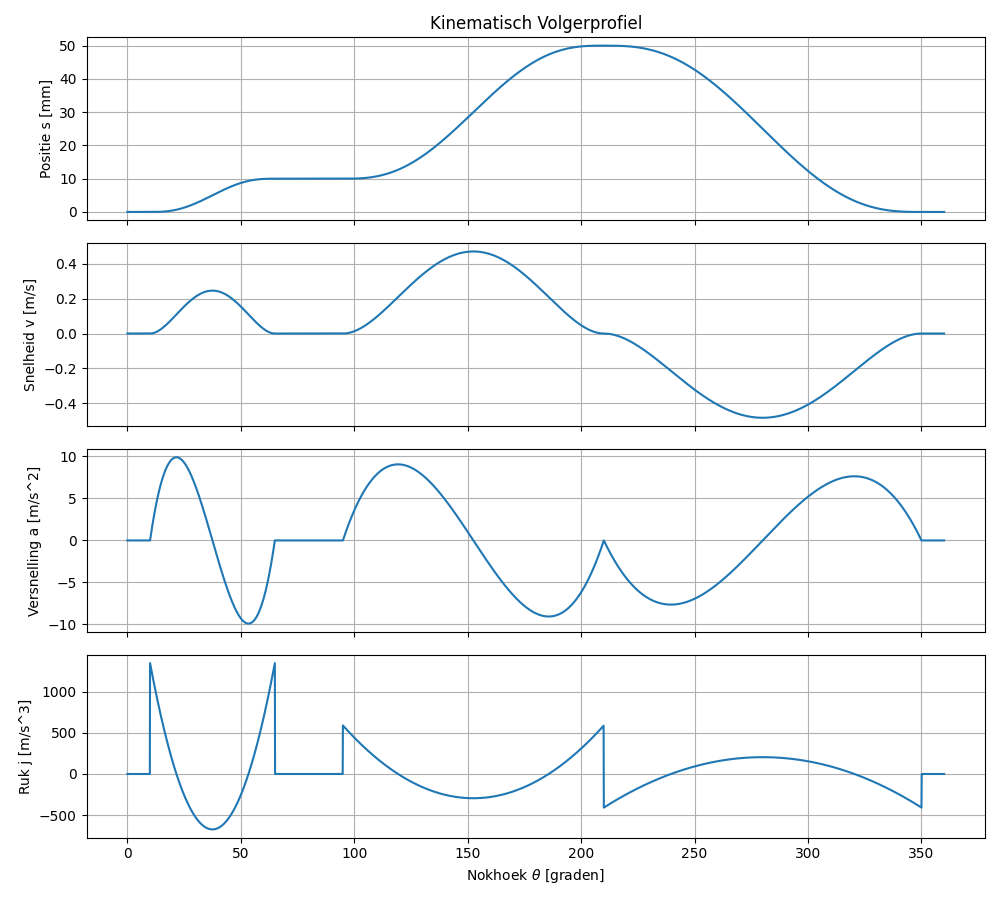

In [4]:
theta_deg = np.linspace(0, 360, 3601)  
theta_rad = np.deg2rad(theta_deg)
time_array = theta_rad / omega

def calc_kinematics_for_profile(theta_array, segments):
    s = np.zeros_like(theta_array)
    v = np.zeros_like(theta_array)
    a = np.zeros_like(theta_array)
    j = np.zeros_like(theta_array)
    
    for (start_hoek, eind_hoek, start_lift, eind_lift, type_wet) in segments:
        beta = eind_hoek - start_hoek
        if beta <= 0:
            beta += 360.0 
            
        beta_rad = np.deg2rad(beta)
        h = eind_lift - start_lift
        
        shifted_deg = (theta_array - start_hoek) % 360.0
        mask = (shifted_deg >= 0) & (shifted_deg <= beta)
        tau = shifted_deg[mask] / beta
        
        if type_wet == 'cycloid':
            y, dy, ddy, dddy = cycloid_law(tau)
        elif type_wet == 'poly5':
            y, dy, ddy, dddy = poly5_law(tau)
        else:
            y, dy, ddy, dddy = dwell_law(tau)
            
        s[mask] = start_lift + h * y
        if type_wet != 'dwell':
            v[mask] = (h / beta_rad) * dy * omega
            a[mask] = (h / (beta_rad**2)) * ddy * (omega**2)
            j[mask] = (h / (beta_rad**3)) * dddy * (omega**3)
            
    return s, v, a, j

profiel_segmenten = [
    (10,   65,  0.0,   0.010, 'poly5'), 
    (65,   95,  0.010, 0.010, 'dwell'), 
    (95,  210,  0.010, 0.050, 'poly5'),
    (210, 350,  0.050, 0.0,   'poly5'), 
    (350,  10,  0.0,   0.0,   'dwell')  
]

s_profiel, v_profiel, a_profiel, j_profiel = calc_kinematics_for_profile(theta_deg, profiel_segmenten)

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
axes[0].plot(theta_deg, s_profiel * 1000)
axes[0].set_ylabel('Positie s [mm]')
axes[0].set_title('Kinematisch Volgerprofiel')
axes[0].grid(True)
axes[1].plot(theta_deg, v_profiel)
axes[1].set_ylabel('Snelheid v [m/s]')
axes[1].grid(True)
axes[2].plot(theta_deg, a_profiel)
axes[2].set_ylabel('Versnelling a [m/s^2]')
axes[2].grid(True)
axes[3].plot(theta_deg, j_profiel)
axes[3].set_ylabel('Ruk j [m/s^3]')
axes[3].set_xlabel(r'Nokhoek $\theta$ [graden]')
axes[3].grid(True)
plt.tight_layout()
plt.show()

### 4. Nokgeometrie: Drukhoek en Ondersnijding

#### 4a. Drukhoek $\alpha$

De drukhoek is de hoek tussen de **normaalkracht op de nok** en de **bewegingsrichting van de volger**. Met excentriciteit $e$:

$$\tan(\alpha) = \frac{\frac{ds}{d\theta} - e}{\sqrt{(R_0 + R_f)^2 - e^2} + s(\theta)}$$

**Richtwaarde:** $|\alpha| < 30°$. Bij grotere drukhoeken neemt de wrijvingskracht snel toe en kan de volger blokkeren (zelfblokkering).

> **Trade-off 1 — R₀ vergroten:** Een grotere basisstraal verkleint de drukhoek, maar neemt meer inbouwruimte en materiaalkosten. Itereer $R_0$ totdat $|\alpha|_{max} < 30°$.
>
> **Trade-off 2 — Excentriciteit e:** Het toevoegen van excentriciteit kan de drukhoek tijdens de **hefsslag** verlagen (asymmetrisch effect). Dit is "gratis" qua maatvoering maar maakt het mechanisme asymmetrisch: de drukhoek bij de terugkeerslag stijgt dan. Ideaal als de terugkeer minder kritisch is.

#### 4b. Lokale Kromtestraal $\rho$ en Ondersnijdingscheck

De kromtestraal van de **pitch curve** (het pad van het rollermiddelpunt) is:

$$\rho_{pitch} = \frac{\left(s_{tot}^2 + \left(\frac{ds}{d\theta} - e\right)^2\right)^{3/2}}{s_{tot}^2 + 2\left(\frac{ds}{d\theta} - e\right)^2 - s_{tot} \cdot \frac{d^2s}{d\theta^2}}$$

**Eis:** $\rho_{pitch} > R_f$ voor alle $\theta$. Als dit niet geldt $\rightarrow$ **ondersnijding**: de volger snijdt in het nokmateriaal en het mechanisme loopt vast.

> **Trade-off Rolstraal $R_f$:** Waarom niet zo klein mogelijk kiezen om ondersnijding te vermijden?
> - Te klein wiel → extreem **hoge contactspanning** (Hertz) → slijtage en vermoeiing
> - Te klein wiel → **geen ruimte voor een lager** in de volger → extra wrijving
> - Optimum: zo groot mogelijk zonder ondersnijding te veroorzaken


Evaluatie Ondersnijding:
 -> Positief: Geen ondersnijding theoretisch aanwezig binnen het ontwerp.


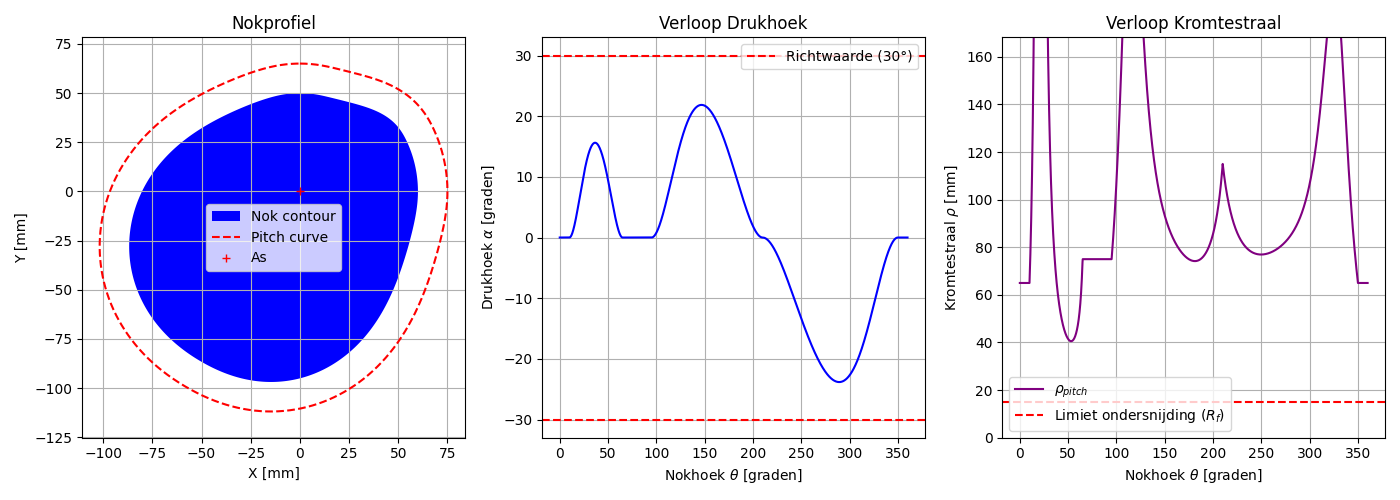

In [5]:
ds_dtheta = v_profiel / omega
d2s_dtheta2 = a_profiel / (omega**2)

s_base = np.sqrt((R_0 + R_f)**2 - e**2)
s_tot = s_base + s_profiel

alpha_rad = np.arctan((ds_dtheta - e) / s_tot)
alpha_deg = np.rad2deg(alpha_rad)

teller = (s_tot**2 + (ds_dtheta - e)**2)**(1.5)
noemer = s_tot**2 + 2*(ds_dtheta - e)**2 - s_tot * d2s_dtheta2
rho_pitch = teller / noemer

X_pitch = s_tot * np.sin(theta_rad) + e * np.cos(theta_rad)
Y_pitch = s_tot * np.cos(theta_rad) - e * np.sin(theta_rad)

X_nok = X_pitch - R_f * np.sin(theta_rad - alpha_rad)
Y_nok = Y_pitch - R_f * np.cos(theta_rad - alpha_rad)

# Numerieke controle op de theorethische limieten ten behoeve van mechanische kwaliteit
print("Evaluatie Ondersnijding:")
if np.any(rho_pitch <= R_f):
    print(" -> Fout: Ondersnijding vastgesteld. Mogelijke lockup en stoot te verwachten, rho_pitch is op minimaal 1 punt in de cyclus lokaal kleiner dan R_f.")
else:
    print(" -> Positief: Geen ondersnijding theoretisch aanwezig binnen het ontwerp.")

fig2, (ax_geom, ax_alpha, ax_rho) = plt.subplots(1, 3, figsize=(14, 5))
ax_geom.fill(X_nok * 1000, Y_nok * 1000, 'b', label='Nok contour')
ax_geom.plot(X_pitch * 1000, Y_pitch * 1000, '--r', label='Pitch curve')
ax_geom.plot(0, 0, 'r+', label='As')
ax_geom.axis('equal')
ax_geom.set_title('Nokprofiel')
ax_geom.set_xlabel('X [mm]')
ax_geom.set_ylabel('Y [mm]')
ax_geom.grid(True)
ax_geom.legend()

ax_alpha.plot(theta_deg, alpha_deg, color='blue')
ax_alpha.axhline(30, color='red', linestyle='--', label='Richtwaarde (30°)')
ax_alpha.axhline(-30, color='red', linestyle='--')
ax_alpha.set_xlabel(r'Nokhoek $\theta$ [graden]')
ax_alpha.set_ylabel(r'Drukhoek $\alpha$ [graden]')
ax_alpha.set_title('Verloop Drukhoek')
ax_alpha.grid(True)
ax_alpha.legend()

ax_rho.plot(theta_deg, rho_pitch * 1000, color='purple', label=r'$\rho_{pitch}$')
ax_rho.axhline(R_f * 1000, color='red', linestyle='--', label='Limiet ondersnijding ($R_f$)')
ax_rho.set_title('Verloop Kromtestraal')
ax_rho.set_ylim(0, max(np.median(rho_pitch)*2000, R_f*3000))
ax_rho.set_xlabel(r'Nokhoek $\theta$ [graden]')
ax_rho.set_ylabel(r'Kromtestraal $\rho$ [mm]')
ax_rho.grid(True)
ax_rho.legend()
plt.tight_layout()
plt.show()

### Trade-off Tabel Bewegingswetten
Tijdens het mondeling examen kan gevraagd worden waarom je voor een bepaalde bewegingswet hebt gekozen (bijv. 5e graads polynoom versus cycloïde). De onderstaande cel berekent de eigenschappen, zodat je de afweging kwantitatief kan staven.


In [6]:
import pandas as pd
import numpy as np

taus = np.linspace(0, 1, 1000)

laws = {
    'Cycloïde': cycloid_law,
    '5e Graads Polynoom (Poly5)': poly5_law
}

data = []
for name, func in laws.items():
    y, dy, ddy, dddy = func(taus)
    data.append({
        'Bewegingswet': name,
        'Max Snelheidsfactor (Cv)': round(np.max(np.abs(dy)), 2),
        'Max Versnellingsfactor (Ca)': round(np.max(np.abs(ddy)), 2),
        'RMS Versnelling': round(np.sqrt(np.mean(ddy**2)), 2),
        'Max Ruk/Jerk factor (Cj)': round(np.max(np.abs(dddy)), 2)
    })

df = pd.DataFrame(data)
display(df)

print("\nInterpretatie voor Mondeling Examen:")
print("- Cycloïde heeft een HOGERE ruk (jerk), maar een LAGERE piekversnelling (Ca).")
print("- Poly5 heeft een HOGERE piekversnelling (Ca), maar is 'zachter' op de grenzen (C^2 continuïteit).")
print("- Als de motor zwak is: kies Cycloïde (lagere Ca).")
print("- Als trillingen door schokken (jerk) kritisch zijn: kies Poly5.")



,Bewegingswet,Max Snelheidsfactor (Cv),Max Versnellingsfactor (Ca),RMS Versnelling,Max Ruk/Jerk factor (Cj)
0,Cycloïde,2.00,6.28,4.44,39.48
1,5e Graads Polynoom (Poly5),1.87,5.77,4.14,60.00



Interpretatie voor Mondeling Examen:
- Cycloïde heeft een HOGERE ruk (jerk), maar een LAGERE piekversnelling (Ca).
- Poly5 heeft een HOGERE piekversnelling (Ca), maar is 'zachter' op de grenzen (C^2 continuïteit).
- Als de motor zwak is: kies Cycloïde (lagere Ca).
- Als trillingen door schokken (jerk) kritisch zijn: kies Poly5.
